# Results 1: EIT Localisation Notebook

This notebook loads the press dataset, cleans the target/EIT columns, subtracts paired baseline readings from contact readings, and trains localisation models to predict x/y target position from EIT channels.

## Workflow

1. Load the raw CSV and inspect the data shape.
2. Clean metadata columns and re-centre target coordinates.
3. Subtract baseline EIT readings from their paired contact readings.
4. Sample 10 spatially ordered target locations along a corner-to-corner diagonal and compare their EIT profiles with a correlation matrix.
5. Build train/test splits from contact rows only.
6. Scale features and fit a linear regression baseline.
7. Compare several localisation models and review diagnostic plots.


## 1. Imports and Display Defaults


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 120)
sns.set_theme(style="whitegrid")


## 2. Load the Raw Data

Set the CSV path, read the file, and do a quick shape/head inspection before modifying anything.


In [2]:
csv_file_path = 'RawData/Press_1027/2026-06-26_19-04-53_4Forces_40x10.csv'

In [3]:
try:
    df = pd.read_csv(csv_file_path)
    print("CSV file loaded successfully!")
except FileNotFoundError:
    print(f"Error: The file at '{csv_file_path}' was not found. Please check the path.")
except Exception as e:
    print(f"An error occurred while loading the CSV: {e}")

CSV file loaded successfully!


In [4]:
df.shape

(32001, 219)

In [5]:
df.head()

,row_type,measurement_index,target_x_mm,target_y_mm,target_force_N,actual_x_mm,actual_y_mm,position_time_s,actual_force_N,force_time_s,eit_0,eit_1,eit_2,eit_3,eit_4,eit_5,eit_6,eit_7,eit_8,eit_9,eit_10,eit_11,eit_12,eit_13,eit_14,eit_15,eit_16,eit_17,eit_18,eit_19,eit_20,eit_21,eit_22,eit_23,eit_24,eit_25,eit_26,eit_27,eit_28,eit_29,eit_30,eit_31,eit_32,eit_33,eit_34,eit_35,eit_36,eit_37,eit_38,eit_39,eit_40,eit_41,eit_42,eit_43,eit_44,eit_45,eit_46,eit_47,eit_48,eit_49,...,eit_149,eit_150,eit_151,eit_152,eit_153,eit_154,eit_155,eit_156,eit_157,eit_158,eit_159,eit_160,eit_161,eit_162,eit_163,eit_164,eit_165,eit_166,eit_167,eit_168,eit_169,eit_170,eit_171,eit_172,eit_173,eit_174,eit_175,eit_176,eit_177,eit_178,eit_179,eit_180,eit_181,eit_182,eit_183,eit_184,eit_185,eit_186,eit_187,eit_188,eit_189,eit_190,eit_191,eit_192,eit_193,eit_194,eit_195,eit_196,eit_197,eit_198,eit_199,eit_200,eit_201,eit_202,eit_203,eit_204,eit_205,eit_206,eit_207,eit_time_s
0,baseline,NaN,NaN,NaN,NaN,NaN,NaN,0.263183,NaN,NaN,0.03902,0.01621,0.002549,0.001968,0.005533,0.007595,0.005926,0.008116,0.009637,0.01358,0.01498,0.01542,0.01237,0.01655,0.002998,0.002204,0.005010,0.007280,0.005739,0.007876,0.009273,0.01320,0.01475,0.01509,0.01212,0.02161,0.02877,0.02747,0.001470,0.002576,0.005418,0.005260,0.006889,0.010390,0.01240,0.01282,0.01034,0.01949,0.03899,0.04484,0.01641,0.011290,0.01535,0.010900,0.003122,0.004834,0.005925,0.006619,0.005725,0.004391,...,0.004695,0.002875,0.003157,0.008540,0.012030,0.01715,0.02354,0.03946,0.000630,0.01489,0.01471,0.01231,0.005768,0.004692,0.002189,0.000939,0.003514,0.006989,0.01298,0.01954,0.001149,0.01523,0.01494,0.01256,0.006463,0.005374,0.002809,0.001356,0.002808,0.006289,0.01188,0.01803,0.03908,0.01243,0.01235,0.01011,0.005654,0.004826,0.002655,0.002144,0.001326,0.004530,0.008455,0.006822,0.02510,0.03938,0.02158,0.01942,0.004339,0.004315,0.006207,0.006450,0.009051,0.007052,0.009477,0.008485,0.01232,0.000588,0.001067,0.263183
1,baseline,1.0,68.333333,24.777778,2.0,68.33,24.78,34.890656,0.0000,NaN,0.03908,0.01643,0.003070,0.002328,0.005146,0.007580,0.005938,0.008527,0.009337,0.01282,0.01529,0.01563,0.01265,0.01678,0.003605,0.002554,0.004695,0.007243,0.005726,0.008221,0.008936,0.01261,0.01499,0.01549,0.01246,0.02172,0.02914,0.02777,0.001441,0.002567,0.005845,0.005308,0.006455,0.009663,0.01265,0.01294,0.01061,0.01979,0.03914,0.04550,0.01672,0.010960,0.01550,0.010150,0.004214,0.004790,0.006597,0.007244,0.006278,0.004062,...,0.004876,0.005037,0.006292,0.008283,0.012540,0.02230,0.02999,0.03986,0.000852,0.01525,0.01512,0.01251,0.006490,0.005386,0.002668,0.001444,0.003315,0.006756,0.01433,0.02141,0.001356,0.01562,0.01547,0.01282,0.007322,0.005956,0.003370,0.001935,0.002421,0.006324,0.01307,0.01975,0.04001,0.01261,0.01262,0.01050,0.006283,0.005275,0.003075,0.002694,0.001137,0.004345,0.009474,0.008429,0.02615,0.03980,0.02177,0.01973,0.004036,0.003975,0.005666,0.006049,0.009042,0.006903,0.009918,0.008551,0.01182,0.000910,0.001343,35.095026
2,contact,1.0,68.333333,24.777778,2.0,68.33,24.78,34.890656,2.0051,54.058350,0.03911,0.01649,0.003089,0.002169,0.004994,0.007684,0.005880,0.008514,0.008860,0.01239,0.01538,0.01572,0.01283,0.01676,0.003626,0.002568,0.004461,0.007221,0.005704,0.008146,0.008715,0.01224,0.01509,0.01558,0.01263,0.02198,0.02849,0.02711,0.001267,0.002837,0.005850,0.005535,0.006299,0.009553,0.01279,0.01316,0.01081,0.02004,0.03906,0.04435,0.01580,0.009949,0.01489,0.009853,0.004906,0.010130,0.006537,0.007191,0.005921,0.003907,...,0.009728,0.007440,0.004408,0.003648,0.009122,0.01696,0.02608,0.04046,0.000406,0.01539,0.01510,0.01265,0.006642,0.005312,0.002764,0.001434,0.003311,0.006894,0.01456,0.02085,0.000884,0.01566,0.01555,0.01282,0.007177,0.005799,0.003313,0.001808,0.002587,0.006772,0.01351,0.01945,0.03985,0.01281,0.01268,0.01073,0.005931,0.004907,0.002948,0.002519,0.001287,0.004751,0.009708,0.009620,0.02736,0.04062,0.02186,0.01984,0.004053,0.004001,0.005601,0.005783,0.009093,0.006821,0.009854,0.008508,0.01187,0.000375,0.00

## 3. Clean Columns and Coordinates

Drop timing/force columns that are not model inputs, then shift target x/y into the working coordinate frame.


In [6]:
# Keep the target location and EIT channels used by the localisation models.
cols_to_exclude = [
    "target_force_N",
    "actual_x_mm",
    "actual_y_mm",
    "position_time_s",
    "force_time_s",
    "eit_time_s",
]
df = df.drop(columns=cols_to_exclude, errors="ignore")


In [7]:
# Re-centre target positions around the sensor/contact coordinate frame.
df.loc[:, "target_x_mm"] = df["target_x_mm"].values - 48
df.loc[:, "target_y_mm"] = df["target_y_mm"].values - 9


In [8]:
# Drop the first row so the remaining data starts on a baseline/contact pair.
df = df.drop(index=0).reset_index(drop=True)
df.head()


,row_type,measurement_index,target_x_mm,target_y_mm,actual_force_N,eit_0,eit_1,eit_2,eit_3,eit_4,eit_5,eit_6,eit_7,eit_8,eit_9,eit_10,eit_11,eit_12,eit_13,eit_14,eit_15,eit_16,eit_17,eit_18,eit_19,eit_20,eit_21,eit_22,eit_23,eit_24,eit_25,eit_26,eit_27,eit_28,eit_29,eit_30,eit_31,eit_32,eit_33,eit_34,eit_35,eit_36,eit_37,eit_38,eit_39,eit_40,eit_41,eit_42,eit_43,eit_44,eit_45,eit_46,eit_47,eit_48,eit_49,eit_50,eit_51,eit_52,eit_53,eit_54,...,eit_148,eit_149,eit_150,eit_151,eit_152,eit_153,eit_154,eit_155,eit_156,eit_157,eit_158,eit_159,eit_160,eit_161,eit_162,eit_163,eit_164,eit_165,eit_166,eit_167,eit_168,eit_169,eit_170,eit_171,eit_172,eit_173,eit_174,eit_175,eit_176,eit_177,eit_178,eit_179,eit_180,eit_181,eit_182,eit_183,eit_184,eit_185,eit_186,eit_187,eit_188,eit_189,eit_190,eit_191,eit_192,eit_193,eit_194,eit_195,eit_196,eit_197,eit_198,eit_199,eit_200,eit_201,eit_202,eit_203,eit_204,eit_205,eit_206,eit_207
0,baseline,1.0,20.333333,15.777778,0.0000,0.03908,0.01643,0.003070,0.002328,0.005146,0.007580,0.005938,0.008527,0.009337,0.01282,0.01529,0.01563,0.01265,0.01678,0.003605,0.002554,0.004695,0.007243,0.005726,0.008221,0.008936,0.01261,0.01499,0.01549,0.01246,0.02172,0.02914,0.02777,0.001441,0.002567,0.005845,0.005308,0.006455,0.009663,0.01265,0.01294,0.01061,0.01979,0.03914,0.04550,0.01672,0.010960,0.01550,0.010150,0.004214,0.004790,0.006597,0.007244,0.006278,0.004062,0.01645,0.01671,0.03125,0.02470,0.02909,...,0.009515,0.004876,0.005037,0.006292,0.008283,0.012540,0.02230,0.02999,0.03986,0.000852,0.01525,0.01512,0.01251,0.006490,0.005386,0.002668,0.001444,0.003315,0.006756,0.01433,0.02141,0.001356,0.01562,0.01547,0.01282,0.007322,0.005956,0.003370,0.001935,0.002421,0.006324,0.01307,0.01975,0.04001,0.01261,0.01262,0.01050,0.006283,0.005275,0.003075,0.002694,0.001137,0.004345,0.009474,0.008429,0.02615,0.03980,0.02177,0.01973,0.004036,0.003975,0.005666,0.006049,0.009042,0.006903,0.009918,0.008551,0.01182,0.000910,0.001343
1,contact,1.0,20.333333,15.777778,2.0051,0.03911,0.01649,0.003089,0.002169,0.004994,0.007684,0.005880,0.008514,0.008860,0.01239,0.01538,0.01572,0.01283,0.01676,0.003626,0.002568,0.004461,0.007221,0.005704,0.008146,0.008715,0.01224,0.01509,0.01558,0.01263,0.02198,0.02849,0.02711,0.001267,0.002837,0.005850,0.005535,0.006299,0.009553,0.01279,0.01316,0.01081,0.02004,0.03906,0.04435,0.01580,0.009949,0.01489,0.009853,0.004906,0.010130,0.006537,0.007191,0.005921,0.003907,0.01647,0.01675,0.02968,0.02323,0.02805,...,0.009565,0.009728,0.007440,0.004408,0.003648,0.009122,0.01696,0.02608,0.04046,0.000406,0.01539,0.01510,0.01265,0.006642,0.005312,0.002764,0.001434,0.003311,0.006894,0.01456,0.02085,0.000884,0.01566,0.01555,0.01282,0.007177,0.005799,0.003313,0.001808,0.002587,0.006772,0.01351,0.01945,0.03985,0.01281,0.01268,0.01073,0.005931,0.004907,0.002948,0.002519,0.001287,0.004751,0.009708,0.009620,0.02736,0.04062,0.02186,0.01984,0.004053,0.004001,0.005601,0.005783,0.009093,0.006821,0.009854,0.008508,0.01187,0.000375,0.000841
2,baseline,2.0,3.923077,8.085470,0.0000,0.03889,0.01629,0.002975,0.002224,0.005335,0.007309,0.005831,0.008260,0.009132,0.01278,0.01513,0.01536,0.01243,0.01640,0.003358,0.002357,0.004981,0.007177,0.005770,0.007697,0.008633,0.01245,0.01480,0.01516,0.01226,0.02149,0.02848,0.02713,0.001395,0.002640,0.006030,0.005472,0.006324,0.009633,0.01255,0.01284,0.01051,0.01958,0.03884,0.04450,0.01609,0.011430,0.01614,0.011400,0.004454,0.004563,0.005889,0.006610,0.005808,0.004190,0.01620,0.01662,0.03106,0.02503,0.02984,...,0.009775,0.004935,0.004421,0.005397,0.008360,0.012270,0.02113,0.02882,0.03972,0.000872,0.01521,0.01499,0.01260,0.006401,0.005276,0.002633,0.001333,0.003121,0.006686,0.01419,0.02122,0.001332,0.01564,0.01540,0.01285,0.006971,0.005688,0.003251,0.001802,0.002379,0.006355,0.01324,0.01969,0.03994,0.01258,0.01255,0.01041,0.006191,0.005235,0.003182,0.002870,0.001106,0.004436,0.009518,0.008230,0.02597,0.03997,0.02163,0.01962,0.004010,0.003896,0.005469,0.005776,0.009305,0.007019,0.010050,0.008689,0.01200

## 4. Baseline Subtraction

Each baseline row is paired with the following contact row. The EIT channels in each contact row are replaced with `contact - baseline`, which reduces drift before modelling.


In [9]:
# Subtract each baseline row from the following contact row for EIT channels only.
eit_cols = df.columns[df.columns.str.startswith("eit_")].tolist()
if not eit_cols:
    raise ValueError("No columns starting with 'eit_' were found.")

if len(df) % 2 != 0:
    raise ValueError(f"Expected baseline/contact pairs, but df has an odd number of rows: {len(df)}")

row_types = df["row_type"].astype(str).str.strip().str.lower()
baseline_ok = row_types.iloc[0::2].eq("baseline").to_numpy()
contact_ok = row_types.iloc[1::2].eq("contact").to_numpy()
print(f"Baseline rows OK: {baseline_ok.all()}, Contact rows OK: {contact_ok.all()}")

if not (baseline_ok.all() and contact_ok.all()):
    bad_pair = next(i for i, ok in enumerate(baseline_ok & contact_ok) if not ok)
    raise ValueError(
        "row_type must alternate baseline/contact. "
        f"First bad pair starts at row {2 * bad_pair}: "
        f"{row_types.iloc[2 * bad_pair]!r}, {row_types.iloc[2 * bad_pair + 1]!r}"
    )

baseline_idx = df.index[0::2]
measurement_idx = df.index[1::2]

df_subtracted = df.copy()
df_subtracted.loc[measurement_idx, eit_cols] = (
    df.loc[measurement_idx, eit_cols].to_numpy(dtype=float)
    - df.loc[baseline_idx, eit_cols].to_numpy(dtype=float)
)
df_subtracted = df_subtracted.drop(columns="row_type", errors="ignore")
df_subtracted.head()


Baseline rows OK: True, Contact rows OK: True


,measurement_index,target_x_mm,target_y_mm,actual_force_N,eit_0,eit_1,eit_2,eit_3,eit_4,eit_5,eit_6,eit_7,eit_8,eit_9,eit_10,eit_11,eit_12,eit_13,eit_14,eit_15,eit_16,eit_17,eit_18,eit_19,eit_20,eit_21,eit_22,eit_23,eit_24,eit_25,eit_26,eit_27,eit_28,eit_29,eit_30,eit_31,eit_32,eit_33,eit_34,eit_35,eit_36,eit_37,eit_38,eit_39,eit_40,eit_41,eit_42,eit_43,eit_44,eit_45,eit_46,eit_47,eit_48,eit_49,eit_50,eit_51,eit_52,eit_53,eit_54,eit_55,...,eit_148,eit_149,eit_150,eit_151,eit_152,eit_153,eit_154,eit_155,eit_156,eit_157,eit_158,eit_159,eit_160,eit_161,eit_162,eit_163,eit_164,eit_165,eit_166,eit_167,eit_168,eit_169,eit_170,eit_171,eit_172,eit_173,eit_174,eit_175,eit_176,eit_177,eit_178,eit_179,eit_180,eit_181,eit_182,eit_183,eit_184,eit_185,eit_186,eit_187,eit_188,eit_189,eit_190,eit_191,eit_192,eit_193,eit_194,eit_195,eit_196,eit_197,eit_198,eit_199,eit_200,eit_201,eit_202,eit_203,eit_204,eit_205,eit_206,eit_207
0,1.0,20.333333,15.777778,0.0000,0.03908,0.01643,0.003070,0.002328,0.005146,0.007580,0.005938,0.008527,0.009337,0.01282,0.01529,0.01563,0.01265,0.01678,0.003605,0.002554,0.004695,0.007243,0.005726,0.008221,0.008936,0.01261,0.01499,0.01549,0.01246,0.02172,0.02914,0.02777,0.001441,0.002567,0.005845,0.005308,0.006455,0.009663,0.01265,0.01294,0.01061,0.01979,0.03914,0.04550,0.01672,0.010960,0.01550,0.010150,0.004214,0.004790,0.006597,0.007244,0.006278,0.004062,0.01645,0.01671,0.03125,0.02470,0.02909,0.02309,...,0.009515,0.004876,0.005037,0.006292,0.008283,0.012540,0.02230,0.02999,0.03986,0.000852,0.01525,0.01512,0.01251,0.006490,0.005386,0.002668,0.001444,0.003315,0.006756,0.01433,0.02141,0.001356,0.01562,0.01547,0.01282,0.007322,0.005956,0.003370,0.001935,0.002421,0.006324,0.01307,0.01975,0.04001,0.01261,0.01262,0.01050,0.006283,0.005275,0.003075,0.002694,0.001137,0.004345,0.009474,0.008429,0.02615,0.03980,0.02177,0.01973,0.004036,0.003975,0.005666,0.006049,0.009042,0.006903,0.009918,0.008551,0.01182,0.000910,0.001343
1,1.0,20.333333,15.777778,2.0051,0.00003,0.00006,0.000019,-0.000159,-0.000152,0.000104,-0.000058,-0.000013,-0.000477,-0.00043,0.00009,0.00009,0.00018,-0.00002,0.000021,0.000014,-0.000234,-0.000022,-0.000022,-0.000075,-0.000221,-0.00037,0.00010,0.00009,0.00017,0.00026,-0.00065,-0.00066,-0.000174,0.000270,0.000005,0.000227,-0.000156,-0.000110,0.00014,0.00022,0.00020,0.00025,-0.00008,-0.00115,-0.00092,-0.001011,-0.00061,-0.000297,0.000692,0.005340,-0.000060,-0.000053,-0.000357,-0.000155,0.00002,0.00004,-0.00157,-0.00147,-0.00104,-0.00073,...,0.000050,0.004852,0.002403,-0.001884,-0.004635,-0.003418,-0.00534,-0.00391,0.00060,-0.000446,0.00014,-0.00002,0.00014,0.000152,-0.000074,0.000096,-0.000010,-0.000004,0.000138,0.00023,-0.00056,-0.000472,0.00004,0.00008,0.00000,-0.000145,-0.000157,-0.000057,-0.000127,0.000166,0.000448,0.00044,-0.00030,-0.00016,0.00020,0.00006,0.00023,-0.000352,-0.000368,-0.000127,-0.000175,0.000150,0.000406,0.000234,0.001191,0.00121,0.00082,0.00009,0.00011,0.000017,0.000026,-0.000065,-0.000266,0.000051,-0.000082,-0.000064,-0.000043,0.00005,-0.000535,-0.000502
2,2.0,3.923077,8.085470,0.0000,0.03889,0.01629,0.002975,0.002224,0.005335,0.007309,0.005831,0.008260,0.009132,0.01278,0.01513,0.01536,0.01243,0.01640,0.003358,0.002357,0.004981,0.007177,0.005770,0.007697,0.008633,0.01245,0.01480,0.01516,0.01226,0.02149,0.02848,0.02713,0.001395,0.002640,0.006030,0.005472,0.006324,0.009633,0.01255,0.01284,0.01051,0.01958,0.03884,0.04450,0.01609,0.011430,0.01614,0.011400,0.004454,0.004563,0.005889,0.006610,0.005808,0.004190,0.01620,0.01662,0.03106,0.02503,0.02984,0.02361,...,0.009775,0.004935,0.004421,0.005397,0.008360,0.012270,0.02113,0.02882,0.03972,0.000872,0.01521,0.01499,0.01260,0.006401,0.005276,0.002633,0.001333,0.003121,0.006686,0.01419,0.02122,0.001332,0.01564,0.01540,0.01285,0.006971,0.005688,0.003251,0.001802,0.002379,0.006355,0.01324,0.01969,0.03994,0.01258,0.01255,0.01041,0.006191,0.005235,0.003182,0.002870,0.001106,0.004436,0.009518,0.008230,0.02597,0.03997,0.02163,0.01962,0.004010,0.003896,0.00

In [10]:
# Keep contact rows for modelling; baseline rows have already served as drift references.
df_model = df_subtracted.loc[measurement_idx].reset_index(drop=True)
df_shuffled = df_model.sample(frac=1, random_state=5).reset_index(drop=True)
df_shuffled.head()


,measurement_index,target_x_mm,target_y_mm,actual_force_N,eit_0,eit_1,eit_2,eit_3,eit_4,eit_5,eit_6,eit_7,eit_8,eit_9,eit_10,eit_11,eit_12,eit_13,eit_14,eit_15,eit_16,eit_17,eit_18,eit_19,eit_20,eit_21,eit_22,eit_23,eit_24,eit_25,eit_26,eit_27,eit_28,eit_29,eit_30,eit_31,eit_32,eit_33,eit_34,eit_35,eit_36,eit_37,eit_38,eit_39,eit_40,eit_41,eit_42,eit_43,eit_44,eit_45,eit_46,eit_47,eit_48,eit_49,eit_50,eit_51,eit_52,eit_53,eit_54,eit_55,...,eit_148,eit_149,eit_150,eit_151,eit_152,eit_153,eit_154,eit_155,eit_156,eit_157,eit_158,eit_159,eit_160,eit_161,eit_162,eit_163,eit_164,eit_165,eit_166,eit_167,eit_168,eit_169,eit_170,eit_171,eit_172,eit_173,eit_174,eit_175,eit_176,eit_177,eit_178,eit_179,eit_180,eit_181,eit_182,eit_183,eit_184,eit_185,eit_186,eit_187,eit_188,eit_189,eit_190,eit_191,eit_192,eit_193,eit_194,eit_195,eit_196,eit_197,eit_198,eit_199,eit_200,eit_201,eit_202,eit_203,eit_204,eit_205,eit_206,eit_207
0,1802.0,28.538462,6.717949,1.0679,-0.00033,0.00006,0.000091,-0.000125,-0.001523,-0.001770,-0.002246,-0.002383,-0.000022,-0.00043,-0.00064,-0.00047,-0.000470,-0.00007,0.000087,-0.000181,-0.001552,-0.001832,-0.002119,-0.002238,-0.000180,-0.000490,-0.00067,-0.00050,-0.000400,-0.00040,-0.00020,-0.00017,-0.000970,-0.001124,-0.001297,-0.001607,0.000077,-0.000184,-0.000527,-0.000490,-0.000357,-0.00023,-0.00042,-0.00093,-0.00036,0.000100,0.000230,-0.000005,0.000097,0.000009,-0.000013,0.000034,-0.000026,-0.000019,0.00001,-0.00022,-0.00177,-0.00122,-0.00162,-0.00182,...,-0.000345,-0.000018,0.000365,0.000035,-0.003592,-0.003762,-0.004934,-0.00533,-0.00069,-0.000774,-0.00063,-0.00056,-0.000330,-0.000033,0.000399,0.000335,0.002567,-0.000054,-0.000597,-0.003943,-0.00005,-0.000630,-0.00062,-0.00060,-0.000352,-0.000047,0.000403,0.000280,0.002361,0.000887,0.000456,-0.003630,0.00020,-0.00041,-0.000590,-0.000580,-0.000384,0.000082,0.000467,0.000306,0.001897,0.001423,0.001501,-0.002905,-0.000179,-0.00073,-0.00074,-0.00043,-0.00030,0.000016,-0.000504,-0.000388,-0.001707,-0.002063,-0.002620,-0.003004,-1.260000e-04,-0.00067,-0.000799,-0.000524
1,10043.0,41.666667,8.740741,4.0333,0.00211,0.00229,0.000219,-0.000230,0.000465,-0.000119,-0.000178,0.000001,-0.000720,-0.00011,-0.00010,0.00003,0.000042,0.00221,0.000262,-0.000147,0.000382,-0.000255,-0.000210,-0.000231,-0.000683,-0.000223,-0.00002,-0.00011,-0.000131,-0.00015,0.00154,0.00189,-0.000455,-0.001236,-0.000844,-0.000866,-0.001225,-0.000328,-0.000052,0.000028,0.000062,-0.00050,0.00235,0.00207,0.00253,0.003876,0.003540,0.003218,0.001842,0.000277,0.000132,0.000227,0.000194,0.001062,0.00226,0.00226,0.00129,0.00223,0.00212,0.00184,...,-0.000748,0.000228,-0.000374,-0.000491,0.001464,0.000340,0.000180,0.00031,-0.00030,-0.000004,-0.00023,-0.00025,-0.000359,-0.000493,0.000266,0.000126,-0.000393,-0.000379,-0.000450,-0.000214,-0.00088,-0.000244,-0.00021,-0.00046,-0.000359,-0.000536,0.000571,0.000213,-0.000454,-0.000383,-0.000351,-0.000422,-0.00101,-0.00065,-0.000127,-0.000206,-0.000089,-0.000363,0.000480,0.000511,0.000079,0.000005,0.000023,-0.000101,-0.000176,-0.00007,-0.00012,-0.00010,-0.00085,0.001214,0.000040,0.000008,0.000920,0.000789,0.000701,0.000694,-9.500000e-05,-0.00012,-0.000090,0.000012
2,11292.0,0.641026,6.039886,1.0106,-0.00029,-0.00023,-0.000162,0.000255,0.000135,0.000080,0.000024,-0.000140,0.000061,-0.00047,-0.00022,-0.00001,-0.003290,-0.00021,-0.000156,0.000180,0.000143,-0.000016,0.000008,-0.000122,0.000073,-0.000400,-0.00032,0.00008,-0.003325,0.00253,0.00001,0.00009,0.000128,0.000054,0.000067,-0.000100,-0.000080,-0.000289,-0.000289,-0.000176,-0.002920,0.00203,-0.00032,0.00041,0.00009,0.000235,0.000350,0.000325,0.000577,-0.000438,-0.000811,-0.000712,-0.001270,-0.000527,-0.00019,-0.00024,0.00015,0.00045,0.00036,0.00040,...,-0.000461,-0.000347,0.000369,0.000667,0.000819,0.000510,0.000770,0.00045,-0.00666,0.006083,-0.00023,-0.00014,-0.000310,-0.000890,-0.000816,-0.000041,-0.000054,0.000874,0.000949,0.000773,0.00215,0.005432,-0.00001,0.00000,-0.000209,-0.000761,-0.000619,-0.000307,-0.000523,

In [11]:
df_model.describe()

,measurement_index,target_x_mm,target_y_mm,actual_force_N,eit_0,eit_1,eit_2,eit_3,eit_4,eit_5,eit_6,eit_7,eit_8,eit_9,eit_10,eit_11,eit_12,eit_13,eit_14,eit_15,eit_16,eit_17,eit_18,eit_19,eit_20,eit_21,eit_22,eit_23,eit_24,eit_25,eit_26,eit_27,eit_28,eit_29,eit_30,eit_31,eit_32,eit_33,eit_34,eit_35,eit_36,eit_37,eit_38,eit_39,eit_40,eit_41,eit_42,eit_43,eit_44,eit_45,eit_46,eit_47,eit_48,eit_49,eit_50,eit_51,eit_52,eit_53,eit_54,eit_55,...,eit_148,eit_149,eit_150,eit_151,eit_152,eit_153,eit_154,eit_155,eit_156,eit_157,eit_158,eit_159,eit_160,eit_161,eit_162,eit_163,eit_164,eit_165,eit_166,eit_167,eit_168,eit_169,eit_170,eit_171,eit_172,eit_173,eit_174,eit_175,eit_176,eit_177,eit_178,eit_179,eit_180,eit_181,eit_182,eit_183,eit_184,eit_185,eit_186,eit_187,eit_188,eit_189,eit_190,eit_191,eit_192,eit_193,eit_194,eit_195,eit_196,eit_197,eit_198,eit_199,eit_200,eit_201,eit_202,eit_203,eit_204,eit_205,eit_206,eit_207
count,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,...,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000
mean,8000.500000,31.000000,13.000000,2.772261,-0.000225,-0.000071,0.000130,0.000147,-0.000049,-0.000143,-0.000129,-0.000211,-0.000194,-0.000188,-0.000174,-0.000173,-0.000185,-0.000082,0.000100,0.000161,-0.000038,-0.000137,-0.000123,-0.000208,-0.000194,-0.000186,-0.000171,-0.000170,-0.000179,-0.000135,-0.001253,-0.001211,0.000183,0.000095,0.000109,0.000045,-0.000070,-0.000026,-0.000031,-0.000030,-0.000048,-0.000007,-0.000231,-0.001685,-0.000325,-0.000085,-0.000021,0.000120,0.000296,0.000098,-0.000014,-0.000019,0.000047,0.000049,-0.000072,-0.000085,-0.001224,-0.000915,-0.000767,-0.000622,...,-0.000008,0.000129,0.000213,0.000062,-0.000028,-0.000194,-0.000187,-0.000379,-0.000506,0.000178,-0.000163,-0.000160,-0.000018,0.000023,0.000071,0.000270,0.000247,0.000021,0.000019,-0.000230,-0.000158,0.000174,-0.000159,-0.000159,-0.000014,0.000023,0.000049,0.000211,0.000183,0.000110,0.000082,-0.000188,-0.000121,-0.000206,-0.000171,-0.000164,-0.000030,0.000086,0.000086,0.000145,0.000106,0.000075,0.000013,-0.000235,-0.000222,-0.000295,-0.000500,-0.000155,-0.000031,0.000023,0.000012,-0.000070,-0.000013,-0.000120,-0.000091,-0.000168,-0.000090,-0.000132,0.000181,0.000175
std,4618.946489,18.943601,5.120398,1.164334,0.002528,0.002074,0.001114,0.001302,0.001167,0.001203,0.001191,0.001241,0.001340,0.001414,0.001240,0.001251,0.001139,0.002099,0.001093,0.001282,0.001150,0.001186,0.001164,0.001218,0.001319,0.001393,0.001233,0.001243,0.001141,0.001457,0.004596,0.004591,0.001174,0.001315,0.001182,0.001316,0.00

## 5. Diagonal Location Correlation Matrix

Subsample 10 target locations along the bottom-left to top-right diagonal of the observed target grid, keep their corresponding baseline-subtracted EIT profiles, and calculate the Pearson correlation between locations. If a location has repeated measurements, its EIT profile is averaged before calculating correlations.


Diagonal target locations used for nearest-neighbour subsampling:


,target_x_mm,target_y_mm
0,-1.000000,4.0
1,6.111111,6.0
2,13.222222,8.0
3,20.333333,10.0
4,27.444444,12.0
5,34.555556,14.0
6,41.666667,16.0
7,48.777778,18.0
8,55.888889,20.0
9,63.000000,22.0


Selected measured target locations:


,target_x_mm,target_y_mm
0,-1.000000,4.000000
1,5.564103,6.159544
2,13.769231,8.256410
3,20.333333,10.222222
4,26.897436,12.096866
5,35.102564,13.874644
6,41.666667,15.555556
7,48.230769,18.803419
8,56.435897,20.205128
9,63.000000,20.000000


Corresponding EIT profiles preview:


,target_x_mm,target_y_mm,eit_0,eit_1,eit_2,eit_3,eit_4,eit_5,eit_6,eit_7,eit_8,eit_9
0,-1.000000,4.000000,-0.000220,-0.000631,-0.000059,0.000431,0.000768,0.000633,0.000710,0.000610,0.001783,0.001115
1,5.564103,6.159544,-0.000322,-0.000315,-0.000010,0.000049,0.000035,-0.000084,-0.000095,-0.000188,-0.000166,-0.000319
2,13.769231,8.256410,-0.000350,-0.000310,-0.000052,0.000034,0.000033,-0.000089,-0.000102,-0.000153,-0.000407,-0.000377
3,20.333333,10.222222,-0.000578,-0.000402,-0.000034,-0.000098,-0.000146,-0.000392,-0.000389,-0.000574,-0.002808,-0.002559
4,26.897436,12.096866,-0.000533,-0.000110,0.000166,-0.000513,-0.002603,-0.003010,-0.003702,-0.003743,-0.000644,-0.000289
5,35.102564,13.874644,-0.000219,-0.000112,0.000056,-0.000295,-0.001315,-0.001302,-0.001023,-0.001050,-0.000220,-0.000140
6,41.666667,15.555556,0.001575,0.001603,-0.000365,0.000359,0.000382,0.000397,0.000367,0.000290,-0.000063,0.000018
7,48.230769,18.803419,0.002697,0.002323,-0.000213,0.000598,-0.000578,-0.000527,-0.000436,-0.000495,-0.000146,0.000007
8,56.435897,20.205128,-0.009209,-0.008926,0.000332,0.001131,-0.000223,-0.000208,-0.000248,-0.000361,-0.000422,-0.000260
9,63.000000,20.000000,-0.015841,-0.002453,0.000612,-0.000689,-0.004425,-0.005531,-0.005112,-0.006117,-0.005626,-0.006948


Correlation matrix between diagonal locations:


,"(-1.0, 4.0)","(5.6, 6.2)","(13.8, 8.3)","(20.3, 10.2)","(26.9, 12.1)","(35.1, 13.9)","(41.7, 15.6)","(48.2, 18.8)","(56.4, 20.2)","(63.0, 20.0)"
"(-1.0, 4.0)",1.000000,0.153138,-0.399318,-0.380271,-0.211181,-0.166159,0.189219,0.094358,0.075221,-0.018686
"(5.6, 6.2)",0.153138,1.000000,0.551128,0.068607,0.284632,0.290266,-0.279967,-0.215147,0.228086,-0.050549
"(13.8, 8.3)",-0.399318,0.551128,1.000000,0.507810,0.478232,0.460030,-0.450403,-0.173089,0.147038,-0.338593
"(20.3, 10.2)",-0.380271,0.068607,0.507810,1.000000,0.110445,0.010414,-0.078658,0.033261,-0.047414,0.018521
"(26.9, 12.1)",-0.211181,0.284632,0.478232,0.110445,1.000000,0.943240,-0.936775,-0.608140,-0.077985,-0.004606
"(35.1, 13.9)",-0.166159,0.290266,0.460030,0.010414,0.943240,1.000000,-0.881706,-0.549920,-0.124074,-0.030416
"(41.7, 15.6)",0.189219,-0.279967,-0.450403,-0.078658,-0.936775,-0.881706,1.000000,0.787106,0.039958,-0.033209
"(48.2, 18.8)",0.094358,-0.215147,-0.173089,0.033261,-0.608140,-0.549920,0.787106,1.000000,-0.236915,-0.401443
"(56.4, 20.2)",0.075221,0.228086,0.147038,-0.047414,-0.077985,-0.124074,0.039958,-0.236915,1.000000,0.038817
"(63.0, 20.0)",-0.018686,-0.050549,-0.338593,0.018521,-0.004606,-0.030416,-0.033209,-0.401443,0.038817,1.000000


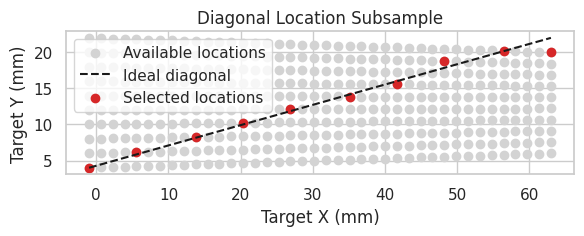

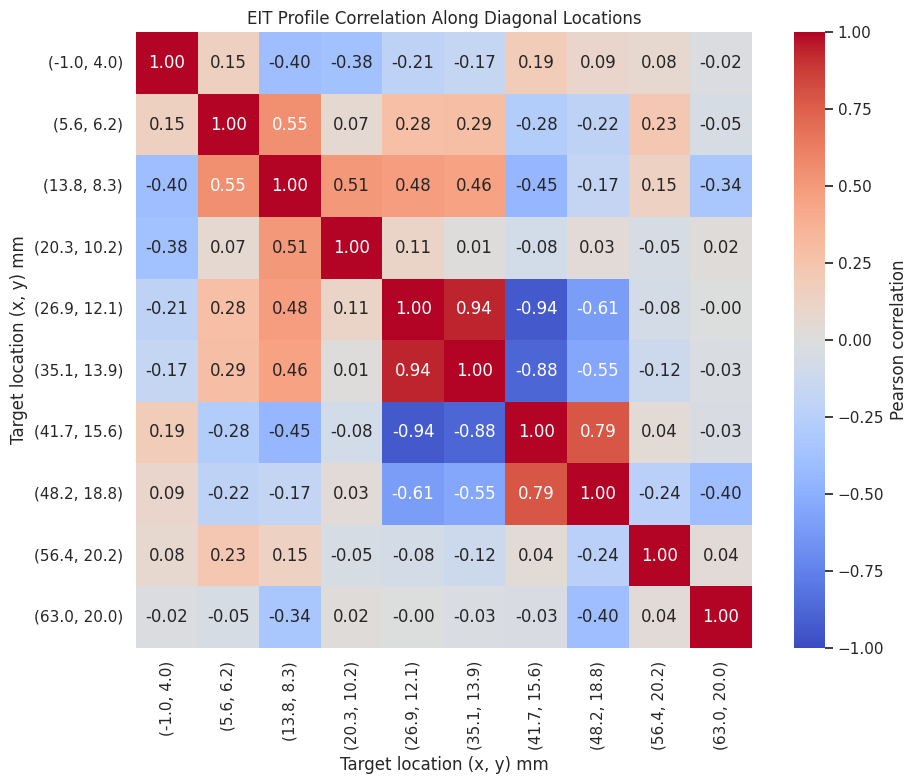

In [12]:
LOCATION_SAMPLE_SIZE = 10
location_cols = ["target_x_mm", "target_y_mm"]

# Average repeated measurements at the same target location into one EIT profile.
location_eit_profiles = (
    df_model
    .groupby(location_cols, as_index=False)[eit_cols]
    .mean()
)

if len(location_eit_profiles) < LOCATION_SAMPLE_SIZE:
    raise ValueError(
        f"Need at least {LOCATION_SAMPLE_SIZE} unique locations, "
        f"but only found {len(location_eit_profiles)}."
    )

x_min, x_max = location_eit_profiles["target_x_mm"].min(), location_eit_profiles["target_x_mm"].max()
y_min, y_max = location_eit_profiles["target_y_mm"].min(), location_eit_profiles["target_y_mm"].max()

# Define an ideal corner-to-corner diagonal, then choose the nearest measured location
# to each evenly spaced point. This keeps the matrix spatially ordered.
diagonal_targets = pd.DataFrame({
    "target_x_mm": np.linspace(x_min, x_max, LOCATION_SAMPLE_SIZE),
    "target_y_mm": np.linspace(y_min, y_max, LOCATION_SAMPLE_SIZE),
})

selected_indices = []
available_indices = set(location_eit_profiles.index)
for _, target in diagonal_targets.iterrows():
    available = location_eit_profiles.loc[list(available_indices), location_cols]
    distances = np.sqrt(
        (available["target_x_mm"] - target["target_x_mm"]) ** 2
        + (available["target_y_mm"] - target["target_y_mm"]) ** 2
    )
    nearest_idx = distances.idxmin()
    selected_indices.append(nearest_idx)
    available_indices.remove(nearest_idx)

sampled_location_eit_profiles = (
    location_eit_profiles
    .loc[selected_indices]
    .reset_index(drop=True)
)

location_labels = sampled_location_eit_profiles.apply(
    lambda row: f"({row['target_x_mm']:.1f}, {row['target_y_mm']:.1f})",
    axis=1,
)

# Columns are sampled locations; rows are EIT channels. Correlating columns compares locations.
eit_by_location = sampled_location_eit_profiles[eit_cols].T
eit_by_location.columns = location_labels
location_correlation_matrix = eit_by_location.corr(method="pearson")

print("Diagonal target locations used for nearest-neighbour subsampling:")
display(diagonal_targets)

print("Selected measured target locations:")
display(sampled_location_eit_profiles[location_cols])

print("Corresponding EIT profiles preview:")
display(sampled_location_eit_profiles[location_cols + eit_cols[:10]])

print("Correlation matrix between diagonal locations:")
display(location_correlation_matrix)

plt.figure(figsize=(6, 6))
plt.gca().set_aspect("equal", adjustable="box")
plt.scatter(
    location_eit_profiles["target_x_mm"],
    location_eit_profiles["target_y_mm"],
    color="lightgray",
    label="Available locations",
)
plt.plot(
    diagonal_targets["target_x_mm"],
    diagonal_targets["target_y_mm"],
    "k--",
    label="Ideal diagonal",
)
plt.scatter(
    sampled_location_eit_profiles["target_x_mm"],
    sampled_location_eit_profiles["target_y_mm"],
    color="tab:red",
    label="Selected locations",
)
plt.xlabel("Target X (mm)")
plt.ylabel("Target Y (mm)")
plt.title("Diagonal Location Subsample")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 8))
sns.heatmap(
    location_correlation_matrix,
    vmin=-1,
    vmax=1,
    cmap="coolwarm",
    square=True,
    annot=True,
    fmt=".2f",
    cbar_kws={"label": "Pearson correlation"},
)
plt.title("EIT Profile Correlation Along Diagonal Locations")
plt.xlabel("Target location (x, y) mm")
plt.ylabel("Target location (x, y) mm")
plt.tight_layout()
plt.show()


## 6. Modelling Dataset and Split

Only contact rows are used for prediction. Baseline rows have already been consumed during subtraction, so they should not enter the model directly.


In [13]:
from sklearn.model_selection import train_test_split

X = df_model.loc[:, eit_cols].reset_index(drop=True)
Y = df_model.loc[:, ["target_x_mm", "target_y_mm"]].reset_index(drop=True)

print("X shape:", X.shape)
print("Y shape:", Y.shape)
display(Y.head())
display(X.head())

X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=44,
)

X_train.shape, X_test.shape


X shape: (16000, 208)
Y shape: (16000, 2)


,target_x_mm,target_y_mm
0,20.333333,15.777778
1,3.923077,8.085470
2,53.153846,12.188034
3,12.128205,4.410256
4,31.820513,6.797721


,eit_0,eit_1,eit_2,eit_3,eit_4,eit_5,eit_6,eit_7,eit_8,eit_9,eit_10,eit_11,eit_12,eit_13,eit_14,eit_15,eit_16,eit_17,eit_18,eit_19,eit_20,eit_21,eit_22,eit_23,eit_24,eit_25,eit_26,eit_27,eit_28,eit_29,eit_30,eit_31,eit_32,eit_33,eit_34,eit_35,eit_36,eit_37,eit_38,eit_39,eit_40,eit_41,eit_42,eit_43,eit_44,eit_45,eit_46,eit_47,eit_48,eit_49,eit_50,eit_51,eit_52,eit_53,eit_54,eit_55,eit_56,eit_57,eit_58,eit_59,...,eit_148,eit_149,eit_150,eit_151,eit_152,eit_153,eit_154,eit_155,eit_156,eit_157,eit_158,eit_159,eit_160,eit_161,eit_162,eit_163,eit_164,eit_165,eit_166,eit_167,eit_168,eit_169,eit_170,eit_171,eit_172,eit_173,eit_174,eit_175,eit_176,eit_177,eit_178,eit_179,eit_180,eit_181,eit_182,eit_183,eit_184,eit_185,eit_186,eit_187,eit_188,eit_189,eit_190,eit_191,eit_192,eit_193,eit_194,eit_195,eit_196,eit_197,eit_198,eit_199,eit_200,eit_201,eit_202,eit_203,eit_204,eit_205,eit_206,eit_207
0,0.00003,0.00006,0.000019,-0.000159,-0.000152,0.000104,-0.000058,-0.000013,-0.000477,-0.00043,0.00009,0.00009,0.00018,-0.00002,0.000021,0.000014,-0.000234,-0.000022,-0.000022,-0.000075,-0.000221,-0.00037,0.00010,0.00009,0.00017,0.00026,-0.00065,-0.00066,-0.000174,0.000270,0.000005,0.000227,-0.000156,-0.000110,0.00014,0.00022,0.00020,0.00025,-0.00008,-0.00115,-0.00092,-0.001011,-0.00061,-0.000297,0.000692,0.005340,-0.000060,-0.000053,-0.000357,-0.000155,0.00002,0.00004,-0.00157,-0.00147,-0.00104,-0.00073,-0.003027,0.003402,-0.000053,-0.000186,...,0.000050,0.004852,0.002403,-0.001884,-0.004635,-0.003418,-0.00534,-0.00391,0.00060,-0.000446,0.00014,-0.00002,0.00014,0.000152,-0.000074,0.000096,-0.000010,-0.000004,0.000138,0.00023,-0.00056,-0.000472,0.00004,0.00008,0.00000,-0.000145,-0.000157,-0.000057,-0.000127,0.000166,0.000448,0.00044,-0.00030,-0.00016,0.00020,0.00006,0.00023,-0.000352,-0.000368,-0.000127,-0.000175,0.000150,0.000406,0.000234,0.001191,0.00121,0.00082,0.00009,0.00011,0.000017,0.000026,-0.000065,-0.000266,0.000051,-0.000082,-0.000064,-0.000043,0.00005,-0.000535,-0.000502
1,-0.00002,0.00002,0.000114,-0.000059,-0.000040,-0.000066,-0.000174,-0.000081,0.000095,0.00006,-0.00002,0.00013,0.00010,0.00029,0.000066,0.000095,-0.000088,-0.000309,-0.000144,0.000393,0.000326,0.00012,0.00018,0.00015,0.00028,0.00003,0.00022,0.00028,-0.000016,-0.000243,0.000150,0.000054,0.000174,0.000237,-0.00005,0.00003,0.00011,0.00007,0.00018,0.00023,0.00025,0.000030,0.00035,-0.000650,-0.000530,0.000325,0.000515,0.000496,0.000222,0.000034,0.00008,-0.00012,-0.00062,0.00019,0.00054,0.00033,0.000246,0.000137,-0.000096,-0.000090,...,-0.000139,-0.000072,0.000130,0.000436,0.000186,-0.000730,-0.00031,0.00008,0.00031,-0.000426,-0.00006,-0.00010,-0.00017,0.000029,-0.000030,-0.000157,-0.000129,-0.000692,-0.000682,-0.00042,-0.00052,-0.000509,-0.00036,-0.00020,-0.00017,0.000040,0.000094,-0.000088,0.000017,-0.000541,-0.000552,-0.00035,-0.00053,-0.00022,0.00007,0.00004,0.00007,-0.000170,-0.000116,-0.000344,-0.000402,-0.000115,-0.000117,0.000078,0.000181,0.00003,0.00010,-0.00002,0.00002,0.000080,0.000247,0.000313,0.000313,-0.000601,-0.000559,-0.000597,-0.000406,-0.00036,-0.000566,-0.000546
2,-0.00192,-0.00195,-0.000332,-0.000015,0.000385,-0.000361,-0.000112,-0.000171,0.000042,0.00021,-0.00031,-0.00008,-0.00018,-0.00203,-0.000417,-0.000045,0.000616,-0.000300,-0.000106,-0.000279,-0.000135,0.00020,0.00000,-0.00007,0.00003,0.00001,-0.00790,-0.00903,0.001913,0.003468,-0.000993,0.000814,0.002511,0.000987,0.00056,0.00034,0.00021,0.00167,-0.00197,-0.00953,-0.00284,-0.003751,-0.00475,-0.004140,-0.001503,0.000735,0.000604,0.000467,0.000251,-0.001770,-0.00176,-0.00185,0.00019,0.00029,0.00022,0.00002,-0.001608,-0.000653,-0.000032,0.000188,...,0.000936,0.000887,-0.000880,-0.001490,-0.000232,-0.000310,-0.00221,-0.00180,-0.00019,0.000127,-0.00002,0.00005,0.00055,0.000724,0.000097,0.000097,0.000034,-0.000016,0.000100,0.00022,-0.00033,0.000202,-0.00011,-0.00004,0.00035,0.000362,0.000152,0.000064,-0.000087,-0.000067,-0.000099,0.00008,-0.00046,-0.00034,0.00004,0.00004,0.00014,0.000347,0.000124,0.000069

((12800, 208), (3200, 208))

In [14]:
X_train.head()

,eit_0,eit_1,eit_2,eit_3,eit_4,eit_5,eit_6,eit_7,eit_8,eit_9,eit_10,eit_11,eit_12,eit_13,eit_14,eit_15,eit_16,eit_17,eit_18,eit_19,eit_20,eit_21,eit_22,eit_23,eit_24,eit_25,eit_26,eit_27,eit_28,eit_29,eit_30,eit_31,eit_32,eit_33,eit_34,eit_35,eit_36,eit_37,eit_38,eit_39,eit_40,eit_41,eit_42,eit_43,eit_44,eit_45,eit_46,eit_47,eit_48,eit_49,eit_50,eit_51,eit_52,eit_53,eit_54,eit_55,eit_56,eit_57,eit_58,eit_59,...,eit_148,eit_149,eit_150,eit_151,eit_152,eit_153,eit_154,eit_155,eit_156,eit_157,eit_158,eit_159,eit_160,eit_161,eit_162,eit_163,eit_164,eit_165,eit_166,eit_167,eit_168,eit_169,eit_170,eit_171,eit_172,eit_173,eit_174,eit_175,eit_176,eit_177,eit_178,eit_179,eit_180,eit_181,eit_182,eit_183,eit_184,eit_185,eit_186,eit_187,eit_188,eit_189,eit_190,eit_191,eit_192,eit_193,eit_194,eit_195,eit_196,eit_197,eit_198,eit_199,eit_200,eit_201,eit_202,eit_203,eit_204,eit_205,eit_206,eit_207
14223,0.00140,0.002600,-0.000173,-0.000959,-0.000659,-0.000755,-0.000775,-0.000710,-0.000710,-0.00085,-0.00078,-0.00088,-0.00086,0.002760,0.000091,-0.000769,-0.000726,-0.000827,-0.000684,-0.000670,-0.000650,-0.00052,-0.00105,-0.00084,-0.000760,-0.00099,0.003300,0.003100,-0.001072,-0.001210,-0.000784,-0.000639,-0.000602,0.000090,-0.000140,-0.000050,0.000270,-0.00041,0.00134,0.00358,0.001070,0.001150,0.001370,0.000832,0.000625,0.000384,0.000429,0.000658,0.000503,0.000422,0.00283,0.002870,0.00016,0.00039,0.00047,0.00013,0.000142,-0.000047,-0.000245,-0.000200,...,0.000130,0.000344,-0.000153,0.000003,-0.000880,-0.000920,-0.00104,-0.00061,-0.00047,0.000568,-0.00076,-0.00094,0.000160,0.000575,-0.000174,-0.000048,-0.000192,-0.000332,-0.000447,-0.000220,-0.00065,0.000342,-0.00073,-0.00102,0.000380,0.000598,0.000004,-0.000050,-0.000009,-0.000298,-0.000307,-0.000095,-0.00066,-0.00034,-0.000670,-0.000650,0.000180,0.000604,-0.000076,0.000021,0.000114,-0.000062,-0.000312,-0.000018,-0.000387,0.00009,-0.00043,-0.00090,-0.00064,0.000420,0.000403,0.000376,0.000056,-0.000130,0.000150,0.000010,0.000099,0.00015,0.000473,0.000400
10799,0.00024,-0.000400,-0.000028,-0.000065,-0.000232,-0.000097,-0.000111,-0.000023,0.000251,-0.00001,-0.00016,-0.00010,0.00003,-0.000330,0.000046,-0.000065,-0.000109,0.000067,-0.000079,0.000071,0.000070,0.00029,0.00006,-0.00016,0.000051,0.00075,-0.000950,-0.001030,0.000148,0.000344,0.000262,0.000268,0.000306,0.000171,0.000057,0.000025,0.000157,0.00093,0.00020,-0.00163,-0.000750,-0.000837,-0.000686,-0.000431,-0.000095,0.000213,0.001095,0.001112,0.000206,0.000088,-0.00040,-0.000340,-0.00113,-0.00117,-0.00094,-0.00105,-0.000183,0.000233,0.001116,0.001200,...,-0.000049,-0.000154,0.000105,0.000377,0.000592,0.000264,-0.00002,0.00053,0.00005,0.000215,-0.00011,-0.00032,-0.000003,0.000885,0.000949,0.000248,0.000366,-0.000433,-0.000455,-0.000132,0.00014,0.000225,-0.00016,-0.00013,0.000000,0.000692,0.000697,0.000050,-0.000092,-0.000824,-0.000727,-0.000385,0.00004,0.00066,-0.000059,0.000097,-0.000009,-0.000171,-0.000092,-0.000398,-0.000386,-0.000320,-0.000408,-0.000369,-0.000171,0.00001,-0.00020,0.00067,0.00070,0.000289,0.000150,0.000573,0.000638,-0.000521,-0.000686,-0.000492,-0.000435,-0.00014,-0.000029,0.000069
15054,0.00018,0.000150,-0.000359,-0.000421,-0.000638,-0.000370,-0.000515,-0.000630,-0.000630,-0.00028,0.00030,0.00018,0.00014,0.000240,-0.000408,-0.000412,-0.000558,-0.000380,-0.000382,-0.000660,-0.000720,-0.00023,0.00028,0.00027,0.000100,0.00018,-0.001170,-0.001030,0.000137,0.000136,0.000018,0.000062,-0.000067,-0.000080,0.000340,0.000250,0.000280,0.00029,0.00018,-0.00264,-0.002210,-0.002660,-0.002850,-0.002326,-0.000451,0.000260,-0.000221,-0.000212,-0.000013,-0.000570,0.00027,0.000190,-0.00395,-0.00458,-0.00486,-0.00427,-0.000495,0.000171,-0.000428,-0.000344,...,-0.000210,0.000144,0.000111,-0.000197,-0.000310,-0.000210,-0.00010,-0.00032,0.00029,0.000146,0.00046,0.00037,0.000360,-0.000114,-0.000313,-0.000094,-0.000007,0.000603,0.000792,0.000330,0.00103,0.000270,0.00037,0.00037,0.000270,-0.000329,-0.000348,-0.000281,-0.000210,0.000632,0.000712,0.00

In [15]:
Y_train.head()

,target_x_mm,target_y_mm
14223,58.076923,5.846154
10799,5.564103,15.931624
15054,25.256410,15.726496
1903,54.794872,13.806268
13610,36.743590,12.131054


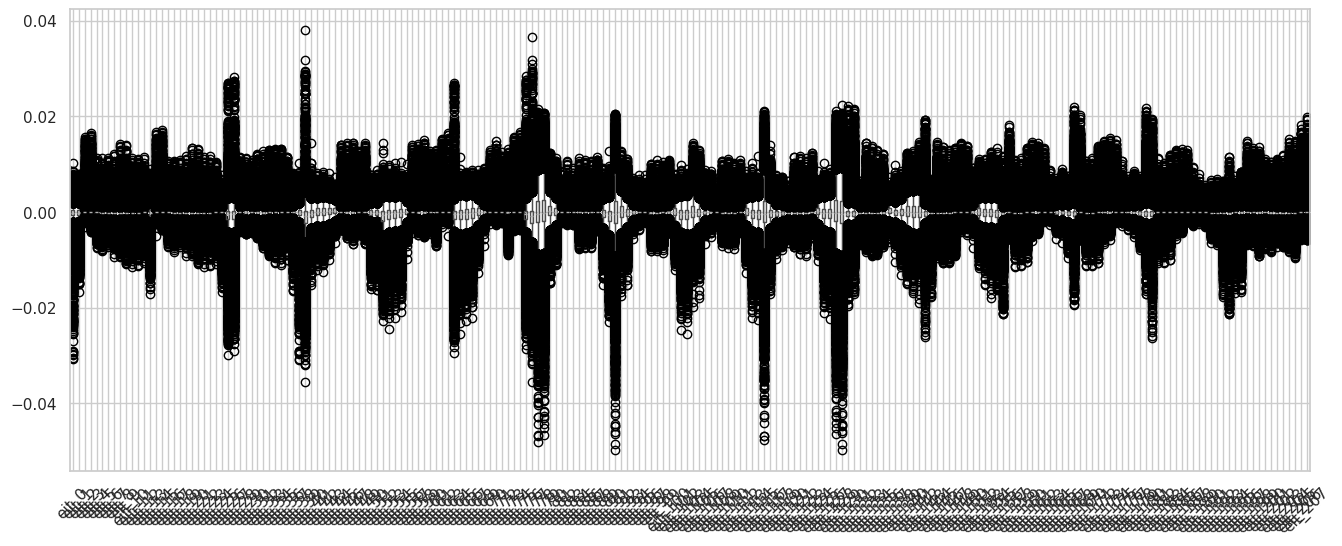

In [16]:
X_train.boxplot(figsize=(16, 6))
plt.xticks(rotation=45)
plt.show()

## 7. Feature Scaling

Fit scaling parameters on `X_train` only so the test split remains genuinely held out.


In [17]:
# Fit the scaler on the training split only, then apply the same transform to test data.
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


,mean,std
eit_0,1.776357e-17,1.0
eit_1,-2.220446e-18,1.0
eit_2,3.330669e-18,1.0
eit_3,-2.775558e-18,1.0
eit_4,4.440892e-18,1.0


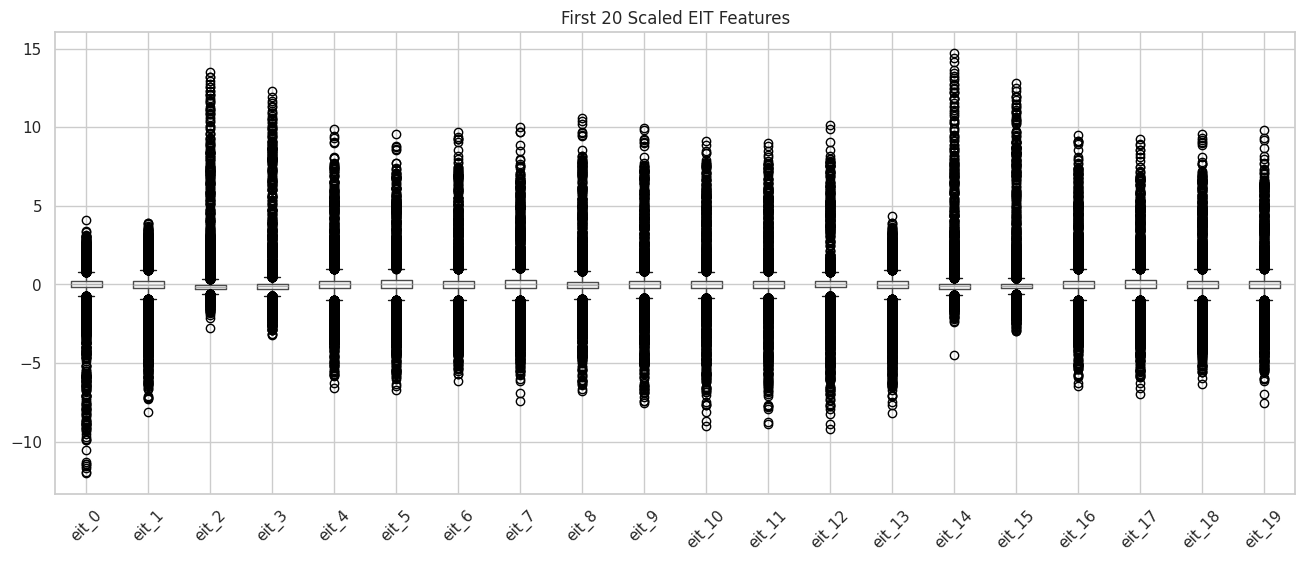

In [18]:
# Convert the scaled arrays back to DataFrames for inspection.
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

scaled_summary = pd.DataFrame({
    "mean": X_train_scaled_df.mean(),
    "std": X_train_scaled_df.std(ddof=0),
})
display(scaled_summary.head())

X_train_scaled_df.iloc[:, :20].boxplot(figsize=(16, 6))
plt.xticks(rotation=45)
plt.title("First 20 Scaled EIT Features")
plt.show()

## 8. Linear Regression Baseline

Start with a simple multi-output linear model. Its predictions and errors are used again in the diagnostic plots at the end.


In [19]:
from sklearn.linear_model import LinearRegression

# Baseline multi-output regression: EIT channels predict x/y location in mm.
model = LinearRegression()
model.fit(X_train_scaled, Y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](2, 208)","[[ 2.69, 9.3 , 4.92,...,-2.04,-1.14, 0.5 ], [ 1.94, 0.5 ,-0.19,...,-0.13, 0.53, 1.26]]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.","ndarray[float64](2,)","[30.98,13.01]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,208
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,208
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](208,)","[747.73,560.29,487.03,..., 2.65, 2.54, 2.25]"


In [20]:
from sklearn.metrics import mean_squared_error, r2_score

# Predict held-out test points and inspect coordinate-wise regression quality.
y_pred = model.predict(X_test_scaled)
y_pred_df = pd.DataFrame(y_pred, columns=Y.columns, index=Y_test.index)

mse = mean_squared_error(Y_test, y_pred, multioutput="raw_values")
r2 = r2_score(Y_test, y_pred, multioutput="raw_values")
rmse = np.sqrt(mse)

target_names = Y.columns
metrics_df = pd.DataFrame({
    "Target": target_names,
    "MSE": mse,
    "RMSE": rmse,
    "R2 Score": r2,
})

print("Coordinate Regression Metrics:")
display(metrics_df)
display(y_pred_df.head())


Coordinate Regression Metrics:


,Target,MSE,RMSE,R2 Score
0,target_x_mm,211.224944,14.533580,0.412524
1,target_y_mm,12.530698,3.539873,0.518841


,target_x_mm,target_y_mm
12604,23.414169,14.878480
10469,18.555173,18.390445
11847,26.779767,14.298991
1544,27.131212,14.216899
6528,25.200214,13.298395


In [21]:
# Summarise linear-model localisation error as Euclidean x/y distance in millimetres.
position_error_mm = np.sqrt(
    (Y_test["target_x_mm"].to_numpy() - y_pred[:, 0]) ** 2
    + (Y_test["target_y_mm"].to_numpy() - y_pred[:, 1]) ** 2
)

print(f"Mean position error: {position_error_mm.mean():.2f} mm")
print(f"Median position error: {np.median(position_error_mm):.2f} mm")
print(f"90th percentile position error: {np.percentile(position_error_mm, 90):.2f} mm")


Mean position error: 12.31 mm
Median position error: 10.24 mm
90th percentile position error: 24.90 mm


## 9. Model Comparison

Run a small leaderboard of candidate localisation models using the same train/test split. Toggle `RUN_SLOW_MODELS` if you want to include the slower Elastic Net and SVR options. The residual MLP first fits a RidgeCV baseline, then learns the remaining x/y residuals with a neural network.


In [22]:
# Compare multiple localisation models on the same train/test split.
# Slow models are disabled by default so the notebook stays responsive.
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, RidgeCV, ElasticNet
from sklearn.cross_decomposition import PLSRegression
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.base import BaseEstimator, RegressorMixin, clone
from time import perf_counter

RUN_SLOW_MODELS = False


class ResidualMLPRegressor(BaseEstimator, RegressorMixin):
    """Fit a base regressor, then learn its remaining x/y residuals with an MLP."""

    def __init__(self, base_estimator=None, residual_estimator=None):
        self.base_estimator = base_estimator
        self.residual_estimator = residual_estimator

    def fit(self, X, y):
        self.base_model_ = clone(self.base_estimator) if self.base_estimator is not None else RidgeCV(
            alphas=np.logspace(-3, 4, 20)
        )
        self.residual_model_ = (
            clone(self.residual_estimator)
            if self.residual_estimator is not None
            else MLPRegressor(
                hidden_layer_sizes=(128, 64),
                activation="relu",
                alpha=1e-4,
                learning_rate_init=1e-3,
                early_stopping=True,
                max_iter=700,
                random_state=0,
            )
        )

        y_array = np.asarray(y)
        self.base_model_.fit(X, y_array)
        residual_target = y_array - np.asarray(self.base_model_.predict(X))
        self.residual_model_.fit(X, residual_target)
        return self

    def predict(self, X):
        base_prediction = np.asarray(self.base_model_.predict(X))
        residual_prediction = np.asarray(self.residual_model_.predict(X))
        return base_prediction + residual_prediction


model_candidates = [
    (
        "Linear Regression",
        Pipeline([
            ("scaler", StandardScaler()),
            ("model", LinearRegression()),
        ]),
        True,
    ),
    (
        "RidgeCV",
        Pipeline([
            ("scaler", StandardScaler()),
            ("model", RidgeCV(alphas=np.logspace(-3, 4, 20))),
        ]),
        True,
    ),
    (
        "Elastic Net",
        Pipeline([
            ("scaler", StandardScaler()),
            ("model", MultiOutputRegressor(
                ElasticNet(alpha=0.001, l1_ratio=0.2, max_iter=20000, random_state=0)
            )),
        ]),
        RUN_SLOW_MODELS,
    ),
    (
        "PLS Regression",
        Pipeline([
            ("scaler", StandardScaler()),
            ("model", PLSRegression(n_components=10)),
        ]),
        True,
    ),
    (
        "PCA + Ridge",
        Pipeline([
            ("scaler", StandardScaler()),
            ("pca", PCA(n_components=30, random_state=0)),
            ("model", RidgeCV(alphas=np.logspace(-3, 4, 20))),
        ]),
        True,
    ),
    (
        "Random Forest",
        RandomForestRegressor(
            n_estimators=250,
            min_samples_leaf=2,
            random_state=0,
            n_jobs=-1,
        ),
        True,
    ),
    (
        "Hist Gradient Boosting",
        MultiOutputRegressor(
            HistGradientBoostingRegressor(
                max_iter=300,
                learning_rate=0.05,
                l2_regularization=0.01,
                random_state=0,
            )
        ),
        True,
    ),
    (
        "MLP Neural Network",
        Pipeline([
            ("scaler", StandardScaler()),
            ("model", MLPRegressor(
                hidden_layer_sizes=(128, 64),
                activation="relu",
                alpha=1e-4,
                learning_rate_init=1e-3,
                early_stopping=True,
                max_iter=500,
                random_state=0,
            )),
        ]),
        True,
    ),
    (
        "Residual MLP",
        Pipeline([
            ("scaler", StandardScaler()),
            ("model", ResidualMLPRegressor()),
        ]),
        True,
    ),
    (
        "SVR RBF",
        Pipeline([
            ("scaler", StandardScaler()),
            ("model", MultiOutputRegressor(
                SVR(kernel="rbf", C=10, epsilon=0.5, gamma="scale")
            )),
        ]),
        RUN_SLOW_MODELS,
    ),
]


In [23]:
def evaluate_localisation_model(name, estimator, X_train, X_test, Y_train, Y_test):
    start = perf_counter()
    estimator.fit(X_train, Y_train)
    y_pred = estimator.predict(X_test)
    elapsed_s = perf_counter() - start

    y_pred = np.asarray(y_pred)
    mae = mean_absolute_error(Y_test, y_pred, multioutput="raw_values")
    rmse = np.sqrt(mean_squared_error(Y_test, y_pred, multioutput="raw_values"))
    r2 = r2_score(Y_test, y_pred, multioutput="raw_values")
    position_error_mm = np.sqrt(
        (Y_test["target_x_mm"].to_numpy() - y_pred[:, 0]) ** 2
        + (Y_test["target_y_mm"].to_numpy() - y_pred[:, 1]) ** 2
    )

    per_target = pd.DataFrame({
        "Model": name,
        "Target": Y_test.columns,
        "MAE": mae,
        "RMSE": rmse,
        "R2 Score": r2,
        "Fit + predict time (s)": elapsed_s,
    })
    summary = {
        "Model": name,
        "Mean position error (mm)": position_error_mm.mean(),
        "Median position error (mm)": np.median(position_error_mm),
        "90th percentile error (mm)": np.percentile(position_error_mm, 90),
        "Mean coordinate RMSE": rmse.mean(),
        "Mean coordinate R2": r2.mean(),
        "Fit + predict time (s)": elapsed_s,
    }
    return per_target, summary, y_pred, estimator

all_metric_rows = []
all_summary_rows = []
model_predictions = {}
estimator_objects = {}

for name, estimator, enabled in model_candidates:
    if not enabled:
        print(f"Skipping {name}. Set RUN_SLOW_MODELS = True to include it.")
        continue

    print(f"Training {name}...")
    per_target_metrics, summary_metrics, y_pred_model, trained_estimator = evaluate_localisation_model(
        name,
        estimator,
        X_train,
        X_test,
        Y_train,
        Y_test,
    )
    all_metric_rows.append(per_target_metrics)
    all_summary_rows.append(summary_metrics)
    model_predictions[name] = y_pred_model
    estimator_objects[name] = trained_estimator

model_metrics_df = pd.concat(all_metric_rows, ignore_index=True)
model_summary_df = pd.DataFrame(all_summary_rows).sort_values("Mean position error (mm)")

print("Model leaderboard, sorted by mean x/y position error:")
display(model_summary_df)

print("Per-target metrics:")
display(model_metrics_df.sort_values(["Target", "RMSE"]))


Training Linear Regression...
Training RidgeCV...
Skipping Elastic Net. Set RUN_SLOW_MODELS = True to include it.
Training PLS Regression...
Training PCA + Ridge...
Training Random Forest...
Training Hist Gradient Boosting...
Training MLP Neural Network...
Training Residual MLP...
Skipping SVR RBF. Set RUN_SLOW_MODELS = True to include it.
Model leaderboard, sorted by mean x/y position error:


,Model,Mean position error (mm),Median position error (mm),90th percentile error (mm),Mean coordinate RMSE,Mean coordinate R2,Fit + predict time (s)
6,MLP Neural Network,2.889881,2.100333,5.679839,2.697221,0.930124,49.162267
7,Residual MLP,3.018245,2.302034,5.819937,2.705527,0.932091,58.080400
4,Random Forest,3.165695,1.639468,7.727193,3.415509,0.894522,27.315844
5,Hist Gradient Boosting,3.562607,2.377024,7.748377,3.336760,0.904371,3.361811
1,RidgeCV,12.309083,10.153389,24.869305,9.024166,0.467155,1.102881
0,Linear Regression,12.312569,10.242727,24.904372,9.036726,0.465683,0.256075
2,PLS Regression,13.766787,12.885725,26.157757,9.686384,0.397535,2.563161
3,PCA + Ridge,13.826039,12.719170,26.201166,9.689516,0.396240,0.272040


Per-target metrics:


,Model,Target,MAE,RMSE,R2 Score,Fit + predict time (s)
12,MLP Neural Network,target_x_mm,2.382454,3.780690,0.960245,49.162267
14,Residual MLP,target_x_mm,2.547438,3.839695,0.958995,58.080400
10,Hist Gradient Boosting,target_x_mm,3.024713,4.866446,0.934133,3.361811
8,Random Forest,target_x_mm,2.617713,4.891795,0.933445,27.315844
2,RidgeCV,target_x_mm,11.585681,14.513254,0.414167,1.102881
0,Linear Regression,target_x_mm,11.587216,14.533580,0.412524,0.256075
6,PCA + Ridge,target_x_mm,13.127180,15.688610,0.315437,0.272040
4,PLS Regression,target_x_mm,13.062404,15.692786,0.315072,2.563161
15,Residual MLP,target_y_mm,1.139858,1.571358,0.905188,58.080400
13,MLP Neural Network,target_y_mm,1.169820,1.613751,0.900003,49.162267


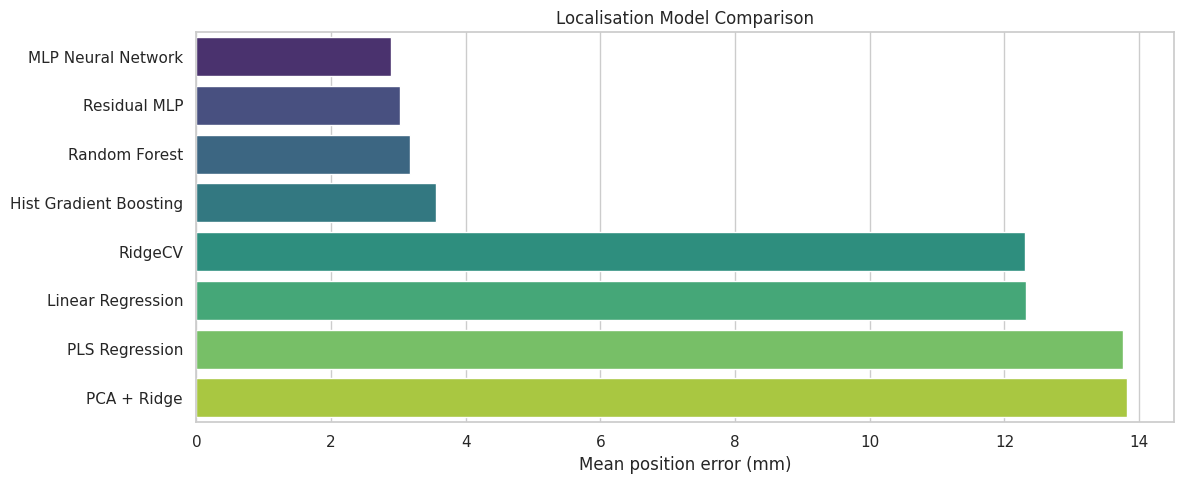

Best model 'MLP Neural Network' saved to disk.


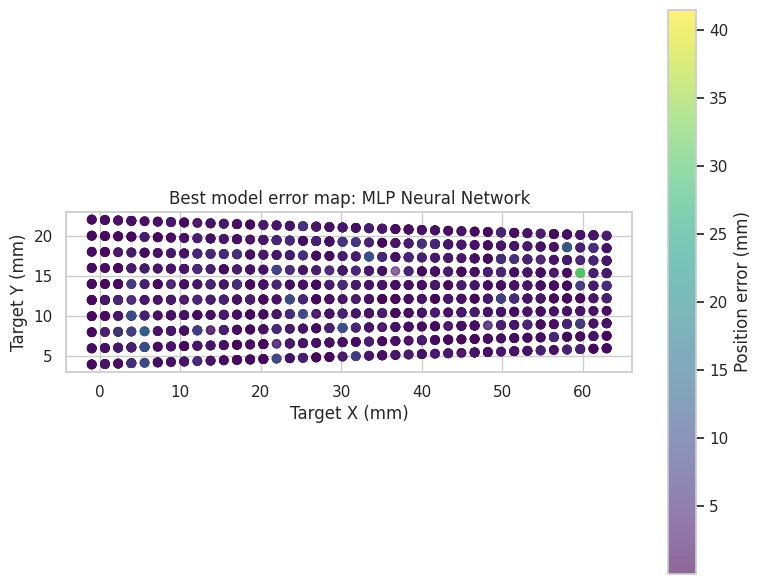

In [24]:
# Visual comparison of localisation error across models.
plt.figure(figsize=(12, 5))
sns.barplot(
    data=model_summary_df,
    x="Mean position error (mm)",
    y="Model",
    hue="Model",
    dodge=False,
    legend=False,
    palette="viridis",
)
plt.xlabel("Mean position error (mm)")
plt.ylabel("")
plt.title("Localisation Model Comparison")
plt.tight_layout()
plt.show()

best_model_name = model_summary_df.iloc[0]["Model"]
best_model = estimator_objects[best_model_name]
#Save the best model for future use
import joblib
joblib.dump(best_model, f"best_localisation_model_{best_model_name.replace(' ', '_')}.joblib")
print(f"Best model '{best_model_name}' saved to disk.")
best_y_pred = model_predictions[best_model_name]
best_position_error_mm = np.sqrt(
    (Y_test["target_x_mm"].to_numpy() - best_y_pred[:, 0]) ** 2
    + (Y_test["target_y_mm"].to_numpy() - best_y_pred[:, 1]) ** 2
)

plt.figure(figsize=(8, 6))
plt.gca().set_aspect("equal", adjustable="box")
plt.xlabel("Target X (mm)")
plt.ylabel("Target Y (mm)")
scatter = plt.scatter(
    Y_test["target_x_mm"],
    Y_test["target_y_mm"],
    c=best_position_error_mm,
    cmap="viridis",
    alpha=0.6,
)
plt.colorbar(scatter, label="Position error (mm)")
plt.title(f"Best model error map: {best_model_name}")
plt.tight_layout()
#export as a vector pdf
plt.savefig(f"best_model_error_map_{best_model_name.replace(' ', '_')}.pdf", format="pdf")
plt.show()



## 10. Linear Baseline Diagnostics

These plots focus on the first linear regression baseline (`model` / `y_pred`) so it is easy to compare the simple reference model against the model leaderboard above.


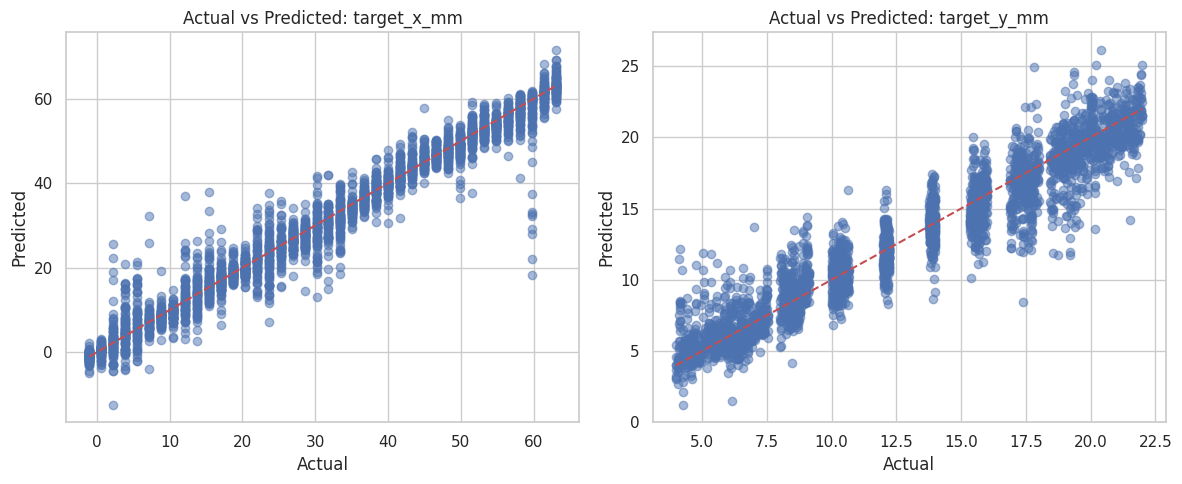

In [25]:
# Linear baseline: actual vs predicted coordinates.
plt.figure(figsize=(12, 5))

for i, col in enumerate(target_names):
    plt.subplot(1, 2, i + 1)
    plt.scatter(Y_test.iloc[:, i], best_y_pred[:, i], alpha=0.5)
    plt.plot(
        [Y_test.iloc[:, i].min(), Y_test.iloc[:, i].max()],
        [Y_test.iloc[:, i].min(), Y_test.iloc[:, i].max()],
        "r--",
    )
    plt.title(f"Actual vs Predicted: {col}")
    plt.xlabel("Actual")
    plt.ylabel("Predicted")

plt.tight_layout()
plt.show()


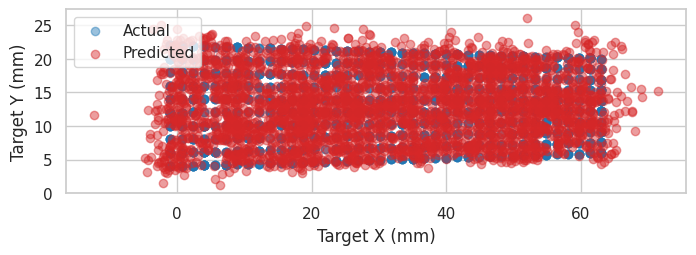

In [26]:
# Linear baseline: actual and predicted test positions on the x/y plane.
plt.figure(figsize=(8, 6))
plt.gca().set_aspect("equal", adjustable="box")
plt.xlabel("Target X (mm)")
plt.ylabel("Target Y (mm)")
plt.scatter(Y_test["target_x_mm"], Y_test["target_y_mm"], color="tab:blue", label="Actual", alpha=0.45)
plt.scatter(best_y_pred[:, 0], best_y_pred[:, 1], color="tab:red", label="Predicted", alpha=0.45)
plt.legend()
plt.show()


/tmp/ipykernel_31444/2319844334.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


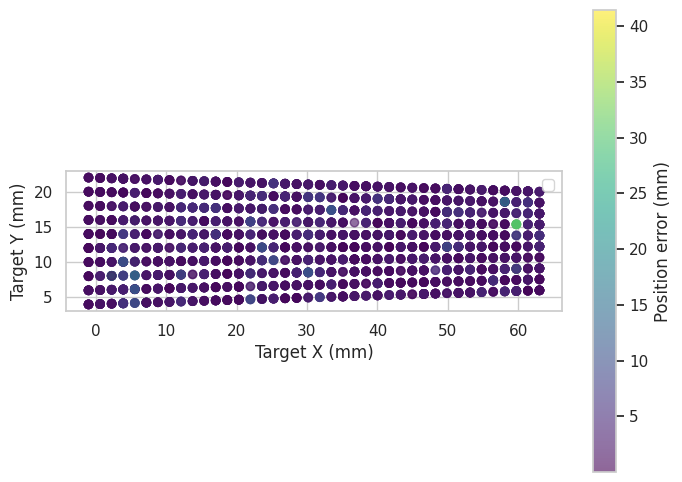

In [27]:
# Linear baseline: test positions coloured by prediction error.
plt.figure(figsize=(8, 6))
plt.gca().set_aspect("equal", adjustable="box")
plt.xlabel("Target X (mm)")
plt.ylabel("Target Y (mm)")
scatter = plt.scatter(
    Y_test["target_x_mm"],
    Y_test["target_y_mm"],
    c=best_position_error_mm,
    cmap="viridis",
    alpha=0.6,
)
# plt.scatter(Y_train["target_x_mm"], Y_train["target_y_mm"], color="red", label="Train", alpha=0.5)
plt.colorbar(scatter, label="Position error (mm)")
plt.legend()
plt.show()
